In [64]:
# File: src/agents/account_creation_agent.py
import sys
import os

# Find the project root folder dynamically
def find_project_root(root_folder_name="Customer_support"):
    current_path = os.path.abspath(os.getcwd())
    while True:
        if os.path.basename(current_path) == root_folder_name:
            return current_path
        parent_path = os.path.dirname(current_path)
        if parent_path == current_path:  # reached system root
            raise Exception(f"Project root folder '{root_folder_name}' not found.")
        current_path = parent_path

# Add the root folder to sys.path
project_root = find_project_root()
sys.path.append(project_root)


### Account creation tool

In [65]:

from src.db.user_db import create_user, get_user_by_phone
from langchain_core.tools import tool
import os
import sys
sys.path.append(os.path.abspath("../../"))
from src.agents.account_creation_agent import account_creation_tool
from src.agents.call_scheduler_agent import call_scheduler_tool
from src.agents.company_info_rag_agent import company_info_rag_tool
from src.agents.product_match_agent import product_match_tool

In [66]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda

from langgraph.prebuilt import ToolNode


def handle_tool_error(state) -> dict:
    error = state.get("error")
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }


def create_tool_node_with_fallback(tools: list) -> dict:
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )


def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

In [67]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph.message import AnyMessage, add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
import os
from datetime import datetime
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

# Load environment variables
load_dotenv()

# ---- Custom Assistant Wrapper ----
class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: dict, config: RunnableConfig):
        configuration = config.get("configurable", {})
        name = configuration.get("name", None)
        phone = configuration.get("Phone no", None)

        # Inject user info into state
        state = {
            **state,
            "user_info": f"{name} ({phone})"
        }

        while True:
            result = self.runnable.invoke(state)
            if not result.tool_calls and (
                not result.content or
                (isinstance(result.content, list) and not result.content[0].get("text"))
            ):
                messages = state.get("messages", []) + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}


# ---- LLM Setup ----
llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-lite", temperature=0.3)

# ---- Prompt ----
primary_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful customer support assistant for Meril Life Sciences. "
            "Use the provided tools to search for company or product or to assist the user's queries. "
            "When searching, be persistent. Expand your query bounds if the first search returns no results. "
            "If a search comes up empty, expand your search before giving up."
            "search google using TavilySearchResults tool if the info is not provided in the company knowledge base."
            "\n\nCurrent user:\n<User>\n{user_info}\n</User>"
            "\nCurrent time: {time}.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

# ---- Tools ----
part_1_tools = [
    TavilySearchResults(max_results=1),
    account_creation_tool,
    call_scheduler_tool,
    company_info_rag_tool,
    product_match_tool,
]

# ---- Final Runnable ----
part_1_assistant_runnable = primary_assistant_prompt | llm.bind_tools(part_1_tools)


In [69]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)
# Define nodes: these do the work
builder.add_node("assistant", Assistant(part_1_assistant_runnable))
builder.add_node("tools", create_tool_node_with_fallback(part_1_tools))
# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")

# The checkpointer lets the graph persist its state
# this is a complete memory for the entire graph.
memory = MemorySaver()
part_1_graph = builder.compile(checkpointer=memory)

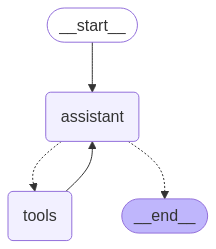

In [70]:
from IPython.display import Image, display

try:
    display(Image(part_1_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [72]:

# ---- Run Simulated Conversation ----
import uuid
import time
from langgraph.graph import StateGraph
from langgraph.graph.message import AnyMessage
from langgraph.graph.message import add_messages
# from langgraph.graph.message import ToolMessage
# Simulated user questions
meril_chatbot_questions = [
    "Tell me about the company Meril.",
    "What products do you have for heart surgery?",
    "Can I get more details on any one of those?",
    "Schedule another call please, it's urgent.",
    "I forgot if I already have an account. My number is 1234567890.",
    "Do you offer stents for cardiac procedures?",
    "How do I place an order for surgical equipment?",
    "Can I get brochures or catalogs for your orthopedic products?",
    "Is there any warranty or support service included with your implants?",
    "I want to speak with a product specialist. Can you arrange that?",
    "Where can I find Meril's nearest distributor or office?",
    "Do you have training or demo sessions for surgeons?",
    "Is there any certification needed to use your robotic surgery tools?",
    "How can hospitals partner with Meril for procurement?",
    "What’s the difference between your bioresorbable and metal stents?",
    "Can you send me a PDF or documentation on your heart valve products?",
    "Do you provide financing or bulk pricing for clinics?",
    "Tell me about your knee replacement systems.",
    "Who can I contact for technical support?",
    "Does Meril operate internationally or only in India?"
]


# meril_chatbot_questions = [
#     "tell me about the values of meril.",
# ]


# Generate session ID
thread_id = str(uuid.uuid4())

# Config with user details
config = {
    "configurable": {
        "name": "Harsh Patel",  # Use your name here
        "Phone no": "6261578341",  # Your test number
        "thread_id": thread_id,
    }
}

# You must define this utility based on your internal `_print_event` logic
_printed = set()

# Loop through and simulate conversation
for question in meril_chatbot_questions:
    print(f"\n[User]: {question}\n")
    events = part_1_graph.stream(
        {"messages": [("user", question)]}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

    time.sleep(10)  # Simulate a delay between user messages


[User]: Tell me about the company Meril.

================================ Human Message =================================

Tell me about the company Meril.
================================== Ai Message ==================================
Tool Calls:
  company_info_rag_tool (58ab2c3e-d2ef-4116-b9bb-46d3b089a8c9)
 Call ID: 58ab2c3e-d2ef-4116-b9bb-46d3b089a8c9
  Args:
    query: Tell me about the company Meril.
[CompanyInfoRAGTool] Running for query: Tell me about the company Meril.
[CompanyInfoRAGTool] Embedding query and querying Pinecone...
[CompanyInfoRAGTool] Generating answer using Gemini...
================================= Tool Message =================================
Name: company_info_rag_tool

Based on the company’s official information, here’s what we know:

Meril Life Sciences is a medical company founded in 2006 as part of the Bilakhia Group's expansion into healthcare technology. It was established by the Bilakhia family in Vapi, Gujarat, India, where it is still headquar